In [1]:
from keras import  models
from keras import layers
import os
from PIL import Image

In [3]:
from PIL import Image
import os

# Define the directories for the training dataset
base_dir = "/Users/tech/Facemask/data"
train_mask_dir = os.path.join(base_dir, 'with_mask')

# Get a list of image files in the directory
image_files = [f for f in os.listdir(train_mask_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Choose one image file to check the size (you can loop through all files if needed)
sample_image_path = os.path.join(train_mask_dir, image_files[0])

# Open the image using PIL
img = Image.open(sample_image_path)

# Get the size of the image
image_size = img.size

# Print the image size
print(f"Image size: {image_size}")


Image size: (201, 250)


In [19]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Define the directories for the training dataset
base_dir = "/Users/tech/Facemask/data"
train_mask_dir = os.path.join(base_dir, 'with_mask')
train_nomask_dir = os.path.join(base_dir, 'without_mask')

# Function to load and preprocess images
def load_and_preprocess(directory, label):
    images = []
    labels = []
    for filename in os.listdir(directory):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(directory, filename)
            img = load_img(img_path, target_size=(201, 250))
            img_array = img_to_array(img)
            img_array /= 255.0  # Rescale to [0,1]
            images.append(img_array)
            labels.append(label)
    return np.array(images), np.array(labels)

# Load and preprocess images with masks
with_mask_images, with_mask_labels = load_and_preprocess(train_mask_dir, label=1)

# Load and preprocess images without masks
without_mask_images, without_mask_labels = load_and_preprocess(train_nomask_dir, label=0)

# Concatenate the data
all_images = np.concatenate([with_mask_images, without_mask_images], axis=0)
all_labels = np.concatenate([with_mask_labels, without_mask_labels], axis=0)

# Shuffle the data
indices = np.arange(all_images.shape[0])
np.random.shuffle(indices)

shuffled_images = all_images[indices]
shuffled_labels = all_labels[indices]

# Print the shapes
print("Shuffled Images Shape:", shuffled_images.shape)
print("Shuffled Labels Shape:", shuffled_labels.shape)


/Users/tech/miniconda3/lib/python3.11/site-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Shuffled Images Shape: (7553, 201, 250, 3)
Shuffled Labels Shape: (7553,)


In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    shuffled_images, shuffled_labels, test_size=0.2, random_state=42
)

# Print the shapes of the training and validation sets
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_val Shape:", X_val.shape)
print("y_val Shape:", y_val.shape)


X_train Shape: (6042, 201, 250, 3)
y_train Shape: (6042,)
X_val Shape: (1511, 201, 250, 3)
y_val Shape: (1511,)


In [21]:

# Define the model
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(201, 250, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [24]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=256, validation_data=(X_val, y_val))


Epoch 1/10
24/24 [==============================] - 269s 11s/step - loss: 0.2345 - accuracy: 0.9032 - val_loss: 0.2481 - val_accuracy: 0.9040
Epoch 2/10
24/24 [==============================] - 270s 11s/step - loss: 0.1903 - accuracy: 0.9262 - val_loss: 0.2347 - val_accuracy: 0.9093
Epoch 3/10
24/24 [==============================] - 265s 11s/step - loss: 0.1556 - accuracy: 0.9381 - val_loss: 0.2306 - val_accuracy: 0.9133
Epoch 4/10
24/24 [==============================] - 267s 11s/step - loss: 0.1229 - accuracy: 0.9522 - val_loss: 0.2609 - val_accuracy: 0.9133
Epoch 5/10
24/24 [==============================] - 260s 11s/step - loss: 0.0905 - accuracy: 0.9667 - val_loss: 0.2222 - val_accuracy: 0.9259
Epoch 6/10
24/24 [==============================] - 304s 13s/step - loss: 0.0610 - accuracy: 0.9775 - val_loss: 0.2525 - val_accuracy: 0.9265
Epoch 7/10
24/24 [==============================] - 262s 11s/step - loss: 0.0572 - accuracy: 0.9811 - val_loss: 0.2431 - val_accuracy: 0.9279
Epoch 

In [25]:
# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

48/48 [==============================] - 15s 315ms/step - loss: 0.3074 - accuracy: 0.9325
Validation Loss: 0.3074
Validation Accuracy: 0.9325


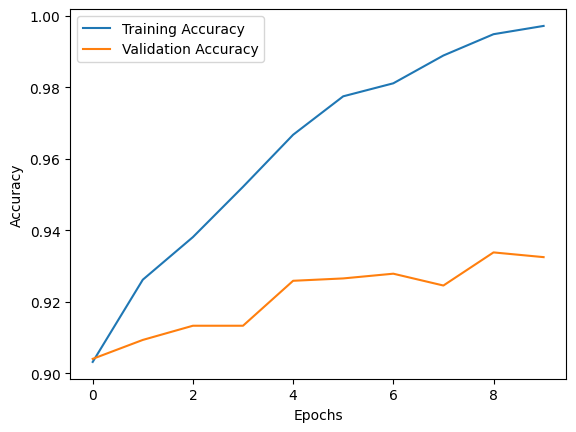

In [27]:
import matplotlib.pyplot as plt
# Plot the training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Save the model
model.save('facemask_model.h5')